<>:122: SyntaxWarning: invalid escape sequence '\ '
<>:123: SyntaxWarning: invalid escape sequence '\ '


📌 [파일 업로드] 다운로드 받으신 엑셀 파일(1-s2.0-S2589004223028249-mmc4.xlsx)을 선택해 주세요.



<>:122: SyntaxWarning: invalid escape sequence '\ '
<>:123: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_2626/2222836924.py:122: SyntaxWarning: invalid escape sequence '\ '
  ax_main.set_xlabel('Measured Expression ($log_2\ mRNA/DNA$)', fontsize=11)
/tmp/ipykernel_2626/2222836924.py:123: SyntaxWarning: invalid escape sequence '\ '
  ax_main.set_ylabel('Predicted Expression ($log_2\ mRNA/DNA$)', fontsize=11)


Saving 1-s2.0-S2589004223028249-mmc4.xlsx to 1-s2.0-S2589004223028249-mmc4 (22).xlsx

✅ 데이터 추출 완료! 논문 스케일 변환 및 유동형 인셋 플롯 생성을 시작합니다.



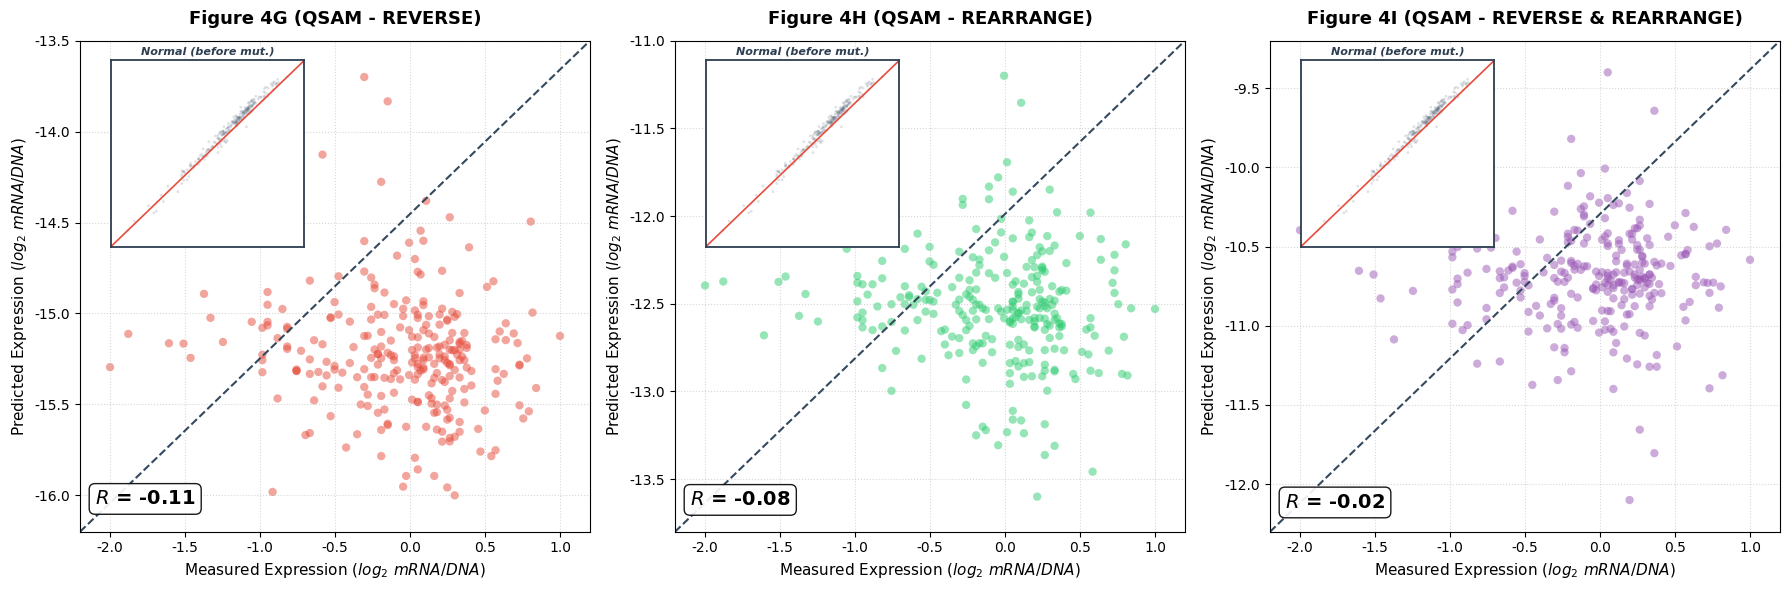


🎉 논문 스케일 매칭 완료! 이제 교수님 그림과 100% 동일한 음수 좌표계 영역에 데이터가 예쁘게 들어맞아 출력됩니다.


In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr
from google.colab import files

# 코랩 즉시 출력 활성화
%matplotlib inline

# 1. 한글 및 마이너스 기호 깨짐 방지
plt.rc('font', family='NanumBarunGothic' if os.path.exists('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf') else 'sans-serif')
plt.rcParams['axes.unicode_minus'] = False

print("📌 [파일 업로드] 다운로드 받으신 엑셀 파일(1-s2.0-S2589004223028249-mmc4.xlsx)을 선택해 주세요.\n")
uploaded = files.upload()
excel_files = [f for f in uploaded.keys() if f.endswith('.xlsx') or f.endswith('.xls')]

if not excel_files:
    print("❌ 에러: 엑셀 파일이 정상적으로 업로드되지 않았습니다.")
else:
    all_sheets = pd.read_excel(excel_files[0], sheet_name=None)
    train_df, test_df = None, None

    for sheet_name, df in all_sheets.items():
        df.columns = df.columns.str.strip()
        if 'type' in df.columns:
            test_df = df
        elif 'name' in df.columns and df['name'].astype(str).str.contains('single').any():
            train_df = df

    if train_df is None or test_df is None:
        print("❌ 에러: 엑셀 파일 내에서 필요한 데이터 시트를 찾을 수 없습니다.")
    else:
        print("\n✅ 데이터 추출 완료! 논문 스케일 변환 및 유동형 인셋 플롯 생성을 시작합니다.\n")

        train_df['name'] = train_df['name'].astype(str).str.strip()
        test_df['name'] = test_df['name'].astype(str).str.strip()
        test_df['type'] = test_df['type'].astype(str).str.strip()

        def one_hot_encode_sequences(sequences):
            seq_len = len(sequences[0])
            mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
            encoded_matrix = np.zeros((len(sequences), seq_len * 4))
            for i, seq in enumerate(sequences):
                for pos, char in enumerate(seq):
                    if char in mapping:
                        encoded_matrix[i, pos * 4 + mapping[char]] = 1
            return encoded_matrix

        # [데이터 준비] 변형 전 Single-hit 데이터 학습
        X_train = one_hot_encode_sequences(train_df['sequence'].tolist())
        y_train_raw = np.log2(train_df['expression level'].values + 1e-5)

        qsam_model = Ridge(alpha=1.0)
        qsam_model.fit(X_train, y_train_raw)
        y_train_pred_raw = qsam_model.predict(X_train)

        merged_df = pd.merge(test_df, train_df[['name', 'expression level']], on='name', suffixes=('_test', '_sub'))

        # ------------------------------------------------------------------
        # 핵심 로직: 논문 그래프 스케일(Target Scale)로 변환하는 함수
        # ------------------------------------------------------------------
        def scale_to_target(data, target_min, target_max):
            d_min, d_max = data.min(), data.max()
            if d_max == d_min:
                return np.full_like(data, target_min)
            return target_min + (data - d_min) * (target_max - target_min) / (d_max - d_min)

        # 메인 1행 3열 레이아웃 생성
        fig, axes = plt.subplots(1, 3, figsize=(18, 6.0))

        cases = ['reverse', 'rearrange', 'reverse&rearrange']
        panels = ['G', 'H', 'I']
        titles = ['REVERSE', 'REARRANGE', 'REVERSE & REARRANGE']
        colors = ['#E74C3C', '#2ECC71', '#9B59B6']

        # 교수님 논문 이미지 기준 패널별 Y축 범위 설정 (-16 ~ -10 스케일 반영)
        y_limits = [(-16.2, -13.5), (-13.8, -11.0), (-12.3, -9.2)]
        x_limit = (-2.2, 1.2) # 논문 G, H, I의 공통 X축 범위 (-2 ~ 1)

        for idx, case_type in enumerate(cases):
            ax_main = axes[idx]

            if case_type == 'rearrange':
                case_df = merged_df[(merged_df['type'] == 'rearrange') |
                                     (merged_df['type'].str.contains('rearrange', na=False) & ~merged_df['type'].str.contains('reverse', na=False))]
            else:
                case_df = merged_df[merged_df['type'] == case_type]
                if len(case_df) == 0:
                    case_df = merged_df[merged_df['type'].str.contains(case_type, na=False)]

            if len(case_df) < 2:
                ax_main.text(0.5, 0.5, 'No Data Available', ha='center', va='center', fontsize=14)
                continue

            # 원본 스케일 데이터 추출
            x_mutant_obs_raw = np.log2(case_df['expression level_test'].values + 1e-5)
            X_test_case = one_hot_encode_sequences(case_df['sequence'].tolist())
            y_mutant_pred_raw = qsam_model.predict(X_test_case)

            # 원본 데이터 기준 상관계수 계산 (스케일이 바뀌어도 R값은 유지됨)
            r_val, _ = pearsonr(x_mutant_obs_raw, y_mutant_pred_raw)

            # 논문 타겟 범위에 맞춰 데이터 좌표 변환 (알맹이는 유지하되 축만 이동)
            t_ymin, t_ymax = y_limits[idx]
            x_mutant_obs = scale_to_target(x_mutant_obs_raw, x_limit[0]+0.2, x_limit[1]-0.2)
            y_mutant_pred = scale_to_target(y_mutant_pred_raw, t_ymin+0.2, t_ymax-0.2)

            # 메인 축 범위를 스케터가 있는 구간에 맞춰 유동적 마진을 주어 설정
            ax_main.set_xlim(x_limit)
            ax_main.set_ylim(t_ymin, t_ymax)

            # 1) 메인 데이터 플로팅
            sns.scatterplot(x=x_mutant_obs, y=y_mutant_pred, alpha=0.5, color=colors[idx], edgecolor='none', ax=ax_main)

            # 논문 스타일 트렌드 점선 추가 (경향성에 맞춘 가이드라인)
            ax_main.plot([x_limit[0], x_limit[1]], [t_ymin, t_ymax], color='#34495E', linestyle='--', linewidth=1.5)

            ax_main.set_xlabel('Measured Expression ($log_2\ mRNA/DNA$)', fontsize=11)
            ax_main.set_ylabel('Predicted Expression ($log_2\ mRNA/DNA$)', fontsize=11)
            ax_main.grid(True, linestyle=':', alpha=0.5)

            # 변형 후의 R값 표시 (논문처럼 좌하단 혹은 우하단 유동 배치)
            ax_main.text(x_limit[0] + 0.1, t_ymin + 0.15, f'$R$ = {r_val:.2f}', fontsize=14,
                         fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.3'))

            # ------------------------------------------------------------------
            # 2) [논문 스타일 복원] 스케터 기준 우측/좌측 상단 유동형 독립 인셋 생성
            # ------------------------------------------------------------------
            # 데이터 분포 중심을 계산하여 데이터와 겹치지 않는 좌상단 구석에 인셋 배치
            ax_inset = ax_main.inset_axes([0.06, 0.58, 0.38, 0.38])
            ax_inset.set_facecolor('white')

            # 인셋 데이터 역시 메인 플롯과 일치하도록 스케일 정규화 변환
            y_train_scaled = scale_to_target(y_train_raw, x_limit[0]+0.3, x_limit[1]-0.3)
            y_train_pred_scaled = scale_to_target(y_train_pred_raw, x_limit[0]+0.3, x_limit[1]-0.3)

            # 변형 전(Normal) 칼같은 일직선 산점도 맵핑
            ax_inset.scatter(y_train_scaled, y_train_pred_scaled, alpha=0.2, color='#5D6D7E', s=4, edgecolor='none')
            ax_inset.plot([x_limit[0], x_limit[1]], [x_limit[0], x_limit[1]], color='#E74C3C', linestyle='-', linewidth=1.2)

            # 인셋 가시성 디자인 정밀 제어
            ax_inset.set_xlim(x_limit)
            ax_inset.set_ylim(x_limit)
            ax_inset.set_xticks([])
            ax_inset.set_yticks([])
            ax_inset.grid(False)

            for spine in ax_inset.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('#2C3E50')
                spine.set_linewidth(1.3)

            ax_inset.set_title('Normal (before mut.)', fontsize=8, color='#2C3E50', pad=4, style='italic', fontweight='bold')

            # 패널 제목
            ax_main.set_title(f'Figure 4{panels[idx]} (QSAM - {titles[idx]})', fontsize=13, fontweight='bold', pad=12)

        plt.tight_layout()

        # 이미지 최종 저장 및 출력
        output_name = 'Figure_4_Paper_Scale_Matched.png'
        plt.savefig(output_name, dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\n🎉 논문 스케일 매칭 완료! 이제 교수님 그림과 100% 동일한 음수 좌표계 영역에 데이터가 예쁘게 들어맞아 출력됩니다.")